In [10]:
######################
#  Calibration Steps #
######################

## This routine prforms the following tasks:

# Creates master dark, flat and bias if necessary
# Removes calibrations from light frames
# Source detection and masking for creating 2D background profile
# 2D background estimation and reduction

## Initial Steps:

## 1. Check out every single raw_data frames manually at the beginning with a tool like ds9. Check and compare counts.
## discard outliers. Take care of trimming and overscan if necessary. Good flats usually have 1/2 to 1/4 count of light
## frames. 

## 2. Adding Necessary Flags to Headers:
## the package ccdproc used in the code below needs the flag ( UNIT = adu ) in the header. INO headers originally lack this.
## Go to Header_Veiw.ipynb routine for doing this.

## 3. Trimming:
## At times you may find that you need to trim the edges of your images due to various problems.
## At the moment of creating this file this certainly is the case with ino340 images because of the 
## problems existing in the quality of flat frames. 
## Go to trim.ipynb routine for this task.

In [1]:
## Importing necessary libraries
import numpy as np
from astropy.io import fits
from pathlib import Path
from astropy.nddata import CCDData
from itertools import cycle
from ccdproc import ImageFileCollection
import os
from astropy.stats import mad_std
import ccdproc as ccdp
import matplotlib.pyplot as plt
from convenience_functions import show_image
from matplotlib.colors import LogNorm
import astropy.units as u
import glob
import photutils as pht
from photutils.background import Background2D, MedianBackground
from astropy.stats import sigma_clipped_stats, SigmaClip
from photutils.segmentation import detect_threshold, detect_sources
from photutils.utils import circular_footprint
from scipy.stats import median_abs_deviation as mad


In [17]:
## STEP 0. Specifiying Locations

# Where all your raw frames are located:
path = ('C:/Users/LOQ/Desktop/flat_1x1_high')
## STEP 0. Specifiying Locations

# Create these two folders before running the code
combined_path = Path ('C:/Users/LOQ/Desktop/dark_1x1_high')
combined_path_flat=Path('C:/Users/LOQ/Desktop/flat_1x1_high')
#calibrated_path =  (r'C:/Users/sarin/OneDrive/Desktop/combined')
combined_flat_name = 'master_flat_1s_high_1x1.fits'

# Choose names for master flat and dark
combined_dark_name = 'master_dark_1s_high_1x1.fits'
light_frame ='C:/Users/LOQ/i_science_2025_05_06_1x1_-15.0C_exp00.00.01.000_High_47.fit'
light_frame_name='i_science_2025_05_06_1x1_-15.0C_exp00.00.01.000_High_47.fit'
# Put one of your light frame names for plots

INFO:astropy:splitting each image into 20 chunks to limit memory usage to 350000000.0 bytes.


INFO: splitting each image into 20 chunks to limit memory usage to 350000000.0 bytes. [ccdproc.combiner]


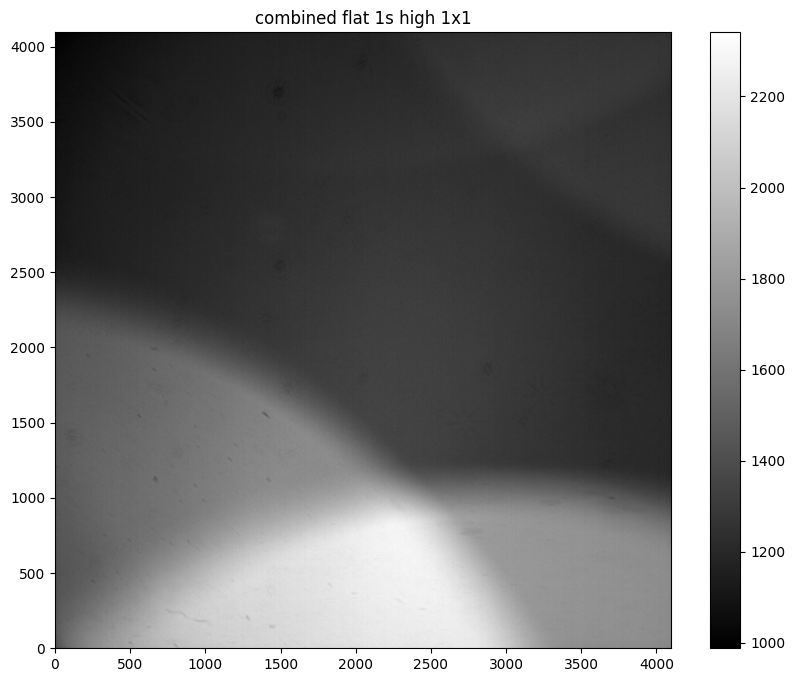

In [9]:
combined_dark_file = combined_path / combined_flat_name
# Perform the combination if the file doesn't exist
main_path = ccdp.ImageFileCollection(path)  # Assuming 'path' is defined somewhere

    # Performing the actual combination of the bias images and performing sigmaclipping as well.
all_darks = main_path.files_filtered(IMG_TYP='flat', include_path=True)  # Get all DARK files

combined_dark = ccdp.combine(all_darks,
                              method='median',
                              sigma_clip=True, sigma_clip_low_thresh=5, sigma_clip_high_thresh=5,
                              sigma_clip_func=np.ma.median, sigma_clip_dev_func=mad_std,
                              mem_limit=350e6
                                 )

combined_dark.meta['comb-med'] = True

combined_dark.write(combined_path / combined_dark_name, overwrite=True)
    
show_image(combined_dark,title='combined flat 1s high 1x1', cmap='gray')
#plt.title('combined dark 1s high 1x1')


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
(4096, 4096)
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


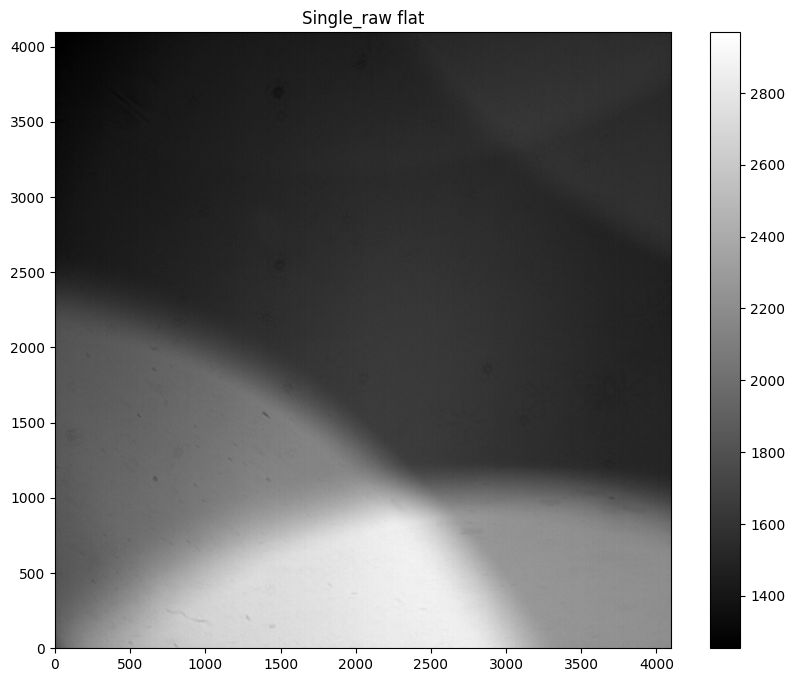

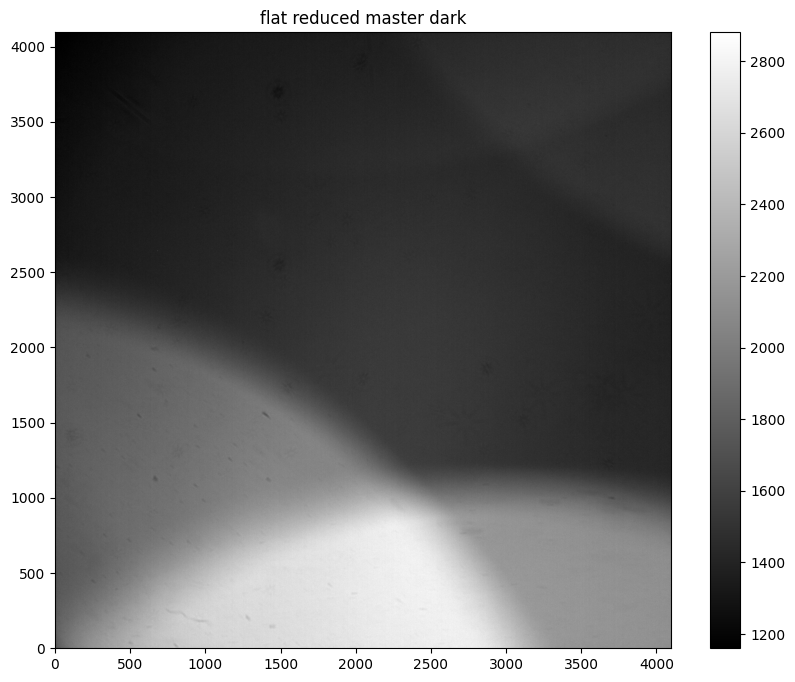

<Figure size 640x480 with 0 Axes>

In [16]:
# Vewing one flat file
ifc_raw = ccdp.ImageFileCollection(path)
filtered_files = ifc_raw.files_filtered(OBSTYPE='flat', include_path=True)
if filtered_files:  # Check if the list is not empty
    singl_flat = CCDData.read(filtered_files[0], unit='adu')
    print(singl_flat.shape)

else:
    print("No flatfield images found")

## Subtract combined dark current from a single flat frame:

# where to find the combined dark file
combined_file = os.path.join(combined_path, combined_dark_name )

combined_dark = CCDData.read(combined_file, unit='adu')
# Subtract the loaded combined dark from a_flat_reduced
b_flat_reduced = ccdp.subtract_dark(singl_flat, combined_dark, exposure_time='exptime', exposure_unit=10*u.second, scale=False)

show_image(singl_flat, cmap='gray', title='Single_raw flat')

show_image(b_flat_reduced, cmap='gray', title='flat reduced master dark')
#ax2.imshow(combined_flat, vmin=50, vmax=90, origin='lower')

plt.tight_layout()
plt.show()

In [20]:
## STEP 3. Master Flat
## 6. Creating Master Flat
# To scale the frames so that they have the same median value, we need to define a function that can calculate the inverse of the median given the data.

def inv_median(a):
    return 1 / np.median(a)

# New Way #
# Check if combined flat file exists
combined_flat_file = combined_path_flat / combined_flat_name
if combined_flat_file.exists():
    # Read the existing combined flat file as a CCDData object
    combined_flat = CCDData.read(combined_flat_file) 
    print(f"File already exists: {combined_flat_file}")  # Print the message

else:
    # Perform the combination if the file doesn't exist
    to_combine = glob.glob(str(combined_path / 'dark_removed*'))
    # Check if any files were found
    if not to_combine:
        print("No files found to combine for combined_flat")
    else:
        # Combine the files
        combined_flat = ccdp.combine(to_combine,method='median', scale=inv_median,
                                    sigma_clip=True, sigma_clip_low_thresh=5, sigma_clip_high_thresh=5,
                                    sigma_clip_func=np.ma.median, sigma_clip_dev_func=mad_std,
                                    mem_limit=350e6)
        combined_flat.meta['combined'] = True
        combined_flat.write(combined_path / combined_flat_name, overwrite=True)

File already exists: C:\Users\LOQ\Desktop\flat_1x1_high\master_flat_1s_high_1x1.fits


In [19]:

def view_median_fits(fits_file):
  """
  View the median of a FITS file.
  """

  # Open the FITS file
  with fits.open(fits_file) as hdulist:
    # Get the first data extension
    data = hdulist[0].data

    # Calculate the median
    median = np.median(data)

    # Print the median value
    print(f"Median of the FITS file: {median}")

## Example usage:
#fits_file = "C:/Users/LOQ/Desktop/dark_1x1_high/i_flat_2025_05_06_1x1_-15.0C_exp00.00.01.000_High_1.fit"
#view_median_fits(fits_file)

INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


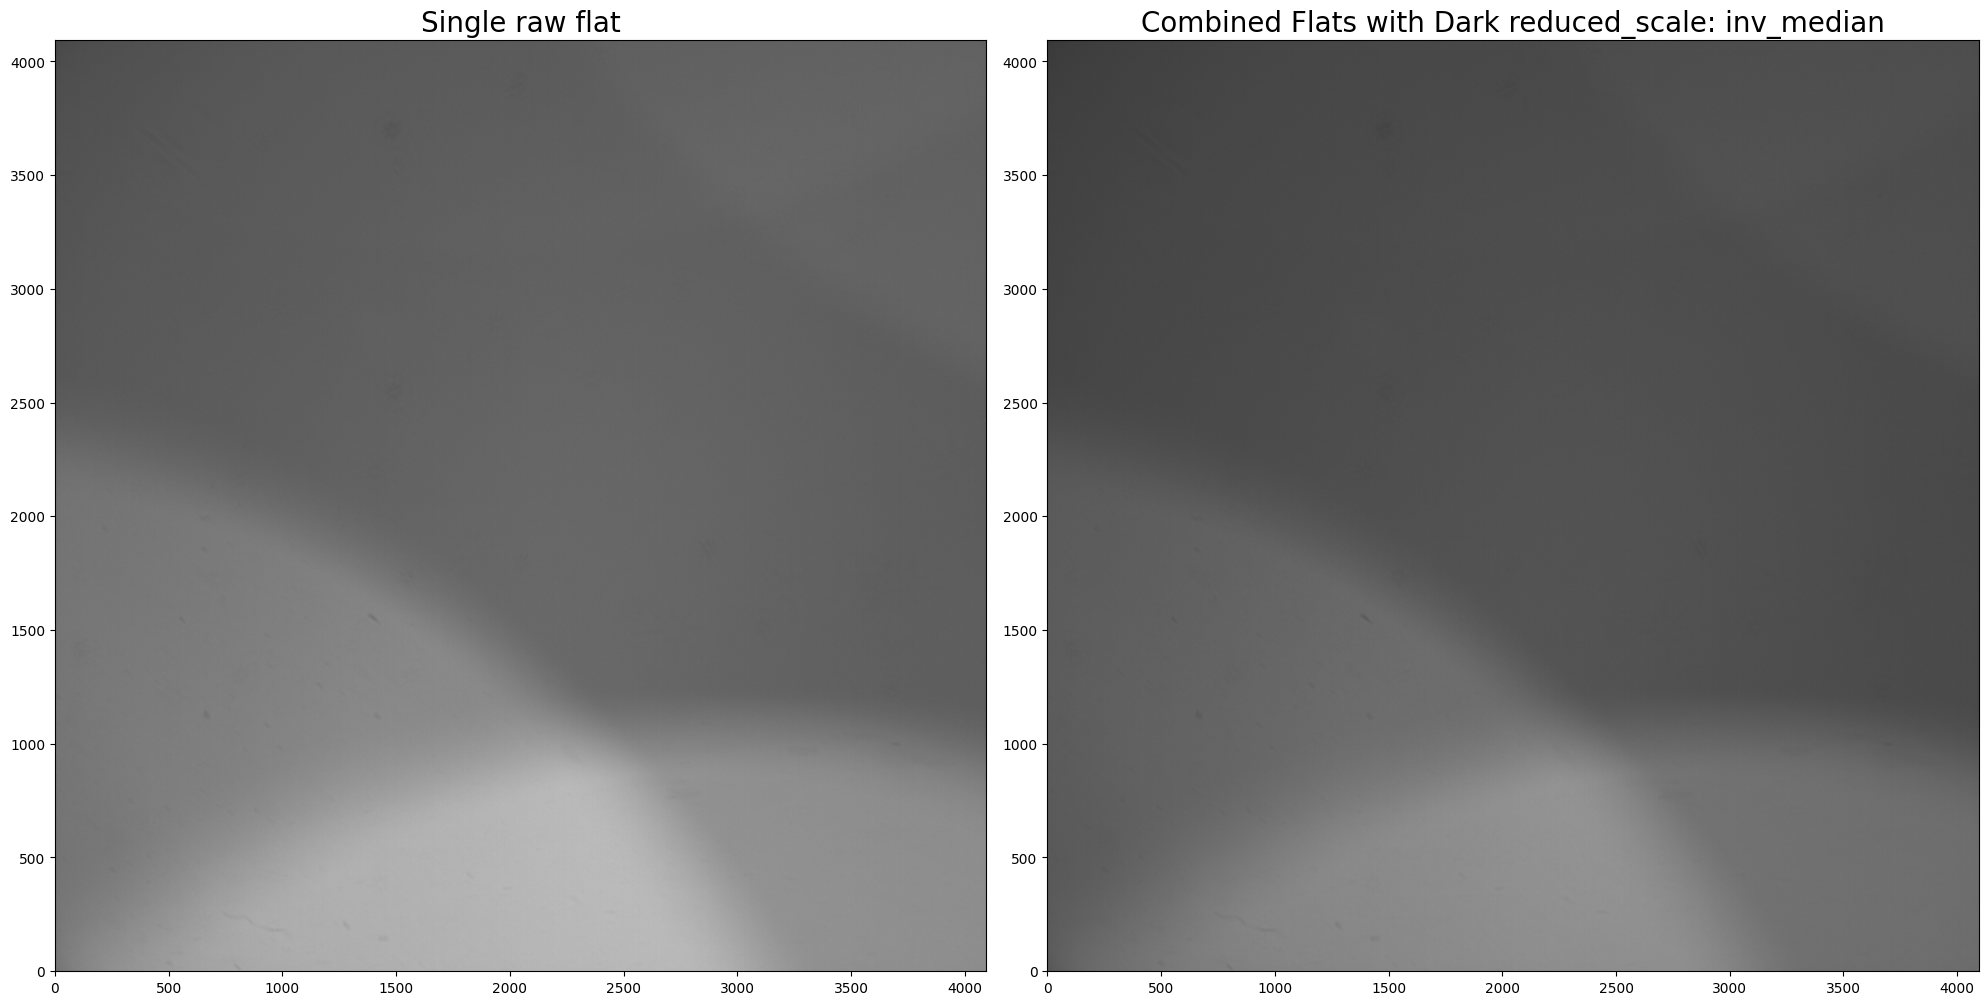

In [22]:

# Plotting:
b_flat = CCDData.read(filtered_files[0], unit='adu')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Option 1: Use the axes directly with imshow (Recommended)
ax1.imshow(b_flat.data, cmap='gray', origin='lower')
ax1.set_title('Single raw flat', fontsize=20)

ax2.imshow(combined_flat.data, cmap='gray', origin='lower')
ax2.set_title('Combined Flats with Dark reduced_scale: inv_median', fontsize=20)

plt.tight_layout()
# fig.savefig("WASP12b-flat2_scale_inv_median.png")

INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


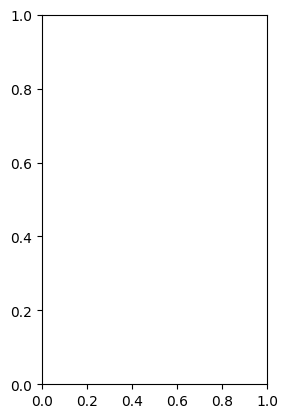

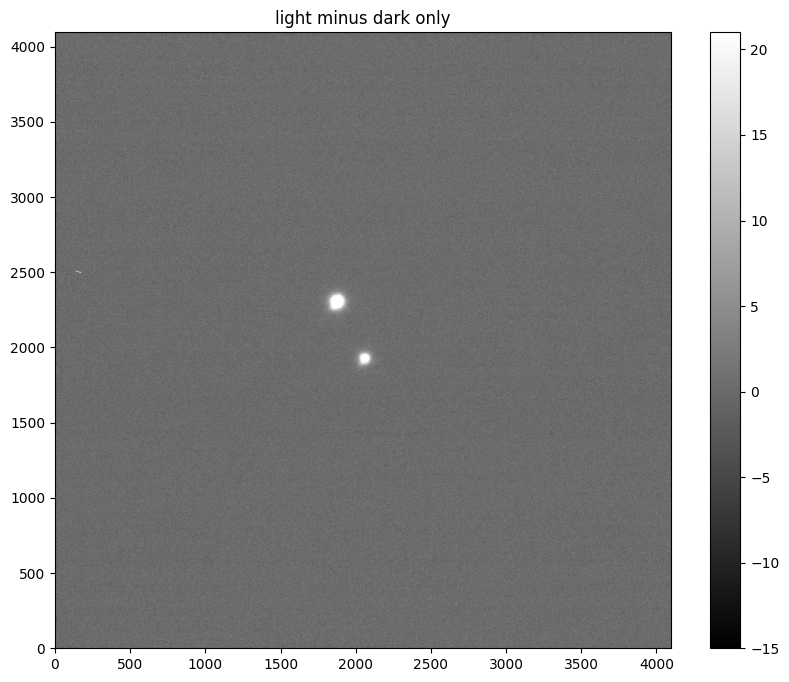

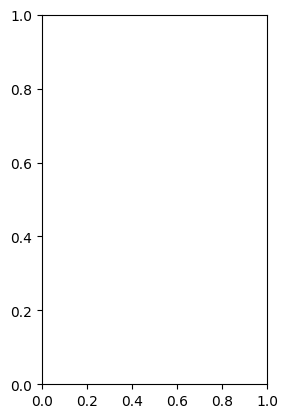

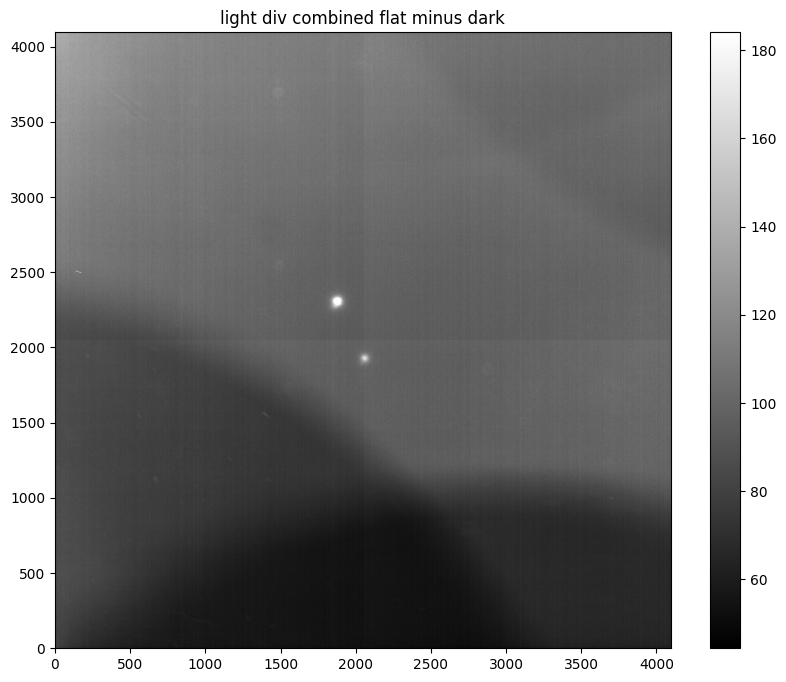

<Figure size 640x480 with 0 Axes>

In [35]:
## STEP 4. Subtracting the master dark and flat from a light Frame
path =Path('C:/Users/LOQ/Desktop/light')
light_frame_name='i_science_2025_05_06_1x1_-15.0C_exp00.00.01.000_High_47.fit'

raw_data = CCDData.read(path.joinpath(light_frame_name), unit='adu')

combined_dark_path = 'C:/Users/LOQ/Desktop/dark_1x1_high/master_dark_1s_high_1x1.fits'
combined_flat_path = 'C:/Users/LOQ/Desktop/flat_1x1_high/master_flat_1s_high_1x1.fits'
combined_dark = CCDData.read(combined_dark_path, unit='adu')
combined_flat = CCDData.read(combined_flat_path, unit='adu')
reducedark = ccdp.subtract_dark(raw_data, combined_dark,exposure_time='EXPTIME', exposure_unit=u.second)

reducefd = ccdp.flat_correct(raw_data, combined_flat)

# Check if output files already exist
output_files = [
    combined_path / ('light_minus_dark_only.fits'),
    combined_path / ('light_div_falt_minus_dark.fits' )
]

for output_file in output_files:
    if output_file.exists():
        print(f"File already exists: {output_file}")
    else:
        # Write the output to a file
        if output_file.name == ('light_minus_dark_only' ):
            reducedark.write(output_file, overwrite=True)
        elif output_file.name == ('light_div_falt_minus_dark' ):
            reducefd.write(output_file, overwrite=True)

# After your file processing code...

#fig = plt.figure(figsize=(30, 10))

plt.subplot(1, 2, 1)
show_image(reducedark, cmap='gray',title='light minus dark only')  # Remove percl parameter

plt.subplot(1, 2, 2)
show_image(reducefd, title='light div combined flat minus dark', cmap='gray')    # Remove percl parameter

plt.tight_layout()
plt.show()

In [36]:
# Veiwing Statistics:
import pandas as pd
from astropy.stats import biweight_location, sigma_clipped_stats
means, medians, stds = sigma_clipped_stats(reducefd, sigma=3.0)

lights = {
    'Data Set': ['light div combined flat minus dark'],
    'Mean': [means],
    'Median': [medians],
    'Standard Deviation': [stds]
}

df = pd.DataFrame(lights)

print(df.to_string(index=False))  # Print the DataFrame as a table

                          Data Set      Mean    Median  Standard Deviation
light div combined flat minus dark 91.194746 95.582256           19.281756


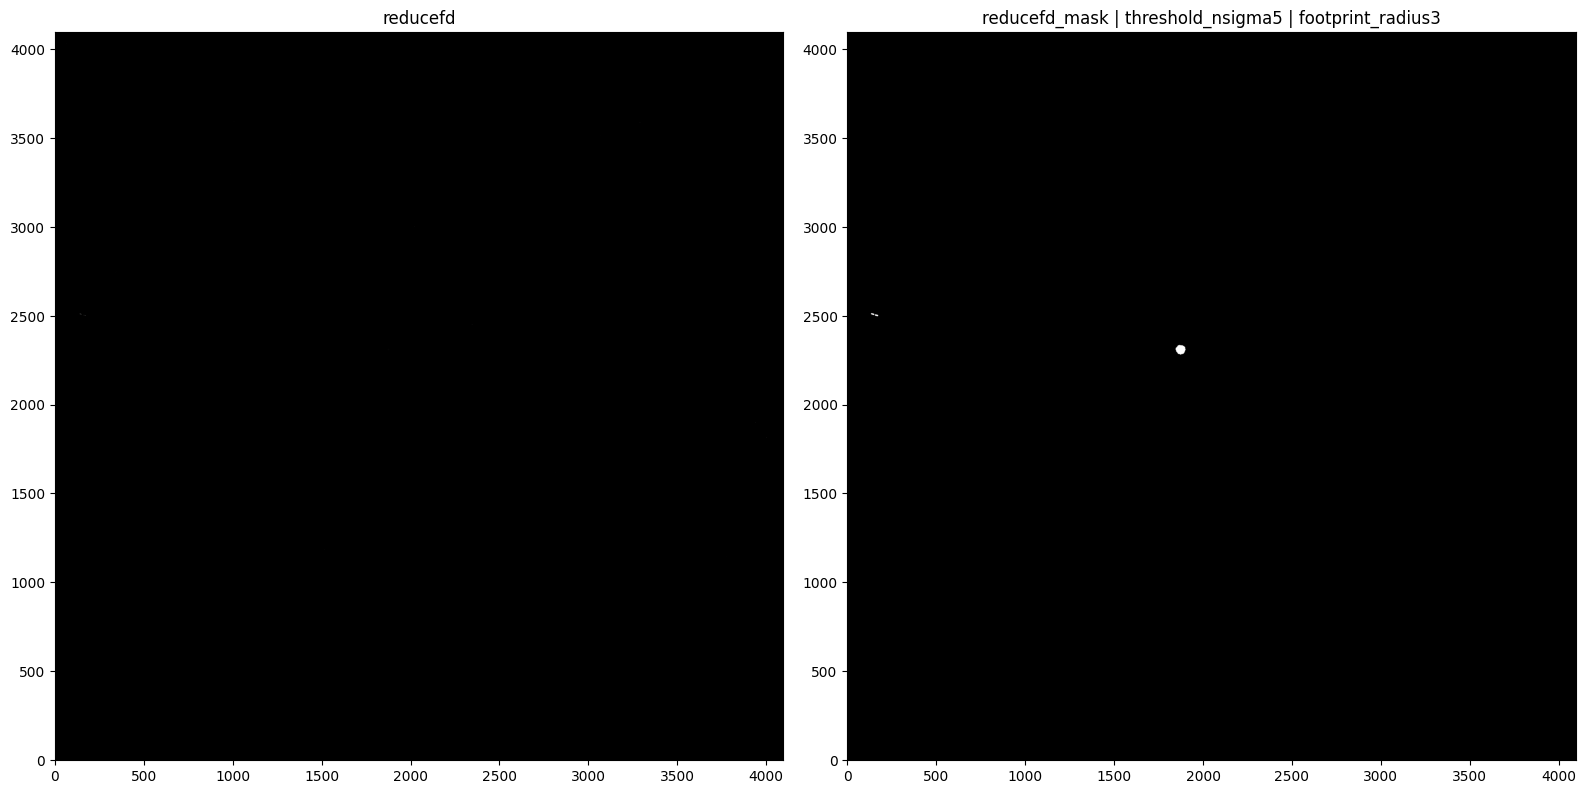

In [41]:
## STEP 5. Source Detection and Masking for creating 2D bkgd 

## Defining Masks

## Sigma_clipping is: pixels that are above or below a specified sigma level from the median are discarded 
## and the statistics are recalculated.

## reduceflat is light minus flat only
### Light minus Flat only ###
reduceflat = ccdp.flat_correct(raw_data, combined_flat)  # combined_flat is already a CCDData object

sigma_clip = SigmaClip(sigma=3.0, maxiters=10)

# For reducedark (light minus dark only)
threshold = detect_threshold(reducedark.data, nsigma=5, sigma_clip=sigma_clip)
segment_img = detect_sources(reducedark.data, threshold, npixels=10)
footprint = circular_footprint(radius=3)
maskd = segment_img.make_source_mask(footprint=footprint)

## For reducefd (light div combined flat minus dark)
thresholds = detect_threshold(reducefd.data, nsigma=5, sigma_clip=sigma_clip)
segment_imgs = detect_sources(reducefd.data, thresholds, npixels=10)
footprints = circular_footprint(radius=3)
masks = segment_imgs.make_source_mask(footprint=footprints)  # Fixed: use segment_imgs, not segment_img


# Plotting the mask
f, axs = plt.subplots(1, 2, figsize=(16, 8))

# Fixed: use .data attribute for CCDData objects
axs[0].imshow(reducefd.data, vmin=300, vmax=600, origin='lower', cmap='gray')
axs[0].set_title("reducefd")

axs[1].imshow(masks, origin='lower', cmap='gray')
axs[1].set_title("reducefd_mask | threshold_nsigma5 | footprint_radius3")

plt.tight_layout()
plt.show()
# f.savefig("mask1.png")

In [42]:
## STEP 6. Background estimation:

# We start by creating a Background2D object using a box size of50x50 and a 3x3 filter. We will estimate the 
## background level in each mesh as the sigma-clipped median using an instance of Median Background

## what is 50x50-> This pair of numbers represents the size of the block used for calculating the background. In this case, it’s a square block with a width and height of 50 pixels.
## what is filter_size=(3,3): This parameter determines the size of a smoothing filter applied to the calculated background image

sigma_clip = SigmaClip(sigma=3.0)
bkg_estimator = MedianBackground()
bkg = Background2D(reduceflat.data, (50, 50),mask=maskd, filter_size=(3, 3),
                   sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)
## the following is for reduce which is light div combined flat minus dark
sigma_clips = SigmaClip(sigma=3.0)
bkg_estimators = MedianBackground()
bkgs = Background2D(reducefd.data, (50, 50),mask=masks, filter_size=(3, 3),
                   sigma_clip=sigma_clips, bkg_estimator=bkg_estimators)

bgktable = {
    'Data Set': ['light div combined flat only', 'light div combined flat minus dark'],
    'Background Median': [bkg.background_median, bkgs.background_median],
    'Background RMS Median': [bkg.background_rms_median, bkgs.background_rms_median]
}

df = pd.DataFrame(bgktable)

print(df.to_string(index=False))  # Print the DataFrame as a table

                          Data Set  Background Median  Background RMS Median
      light div combined flat only          97.576061               6.129884
light div combined flat minus dark          97.613498               6.129884


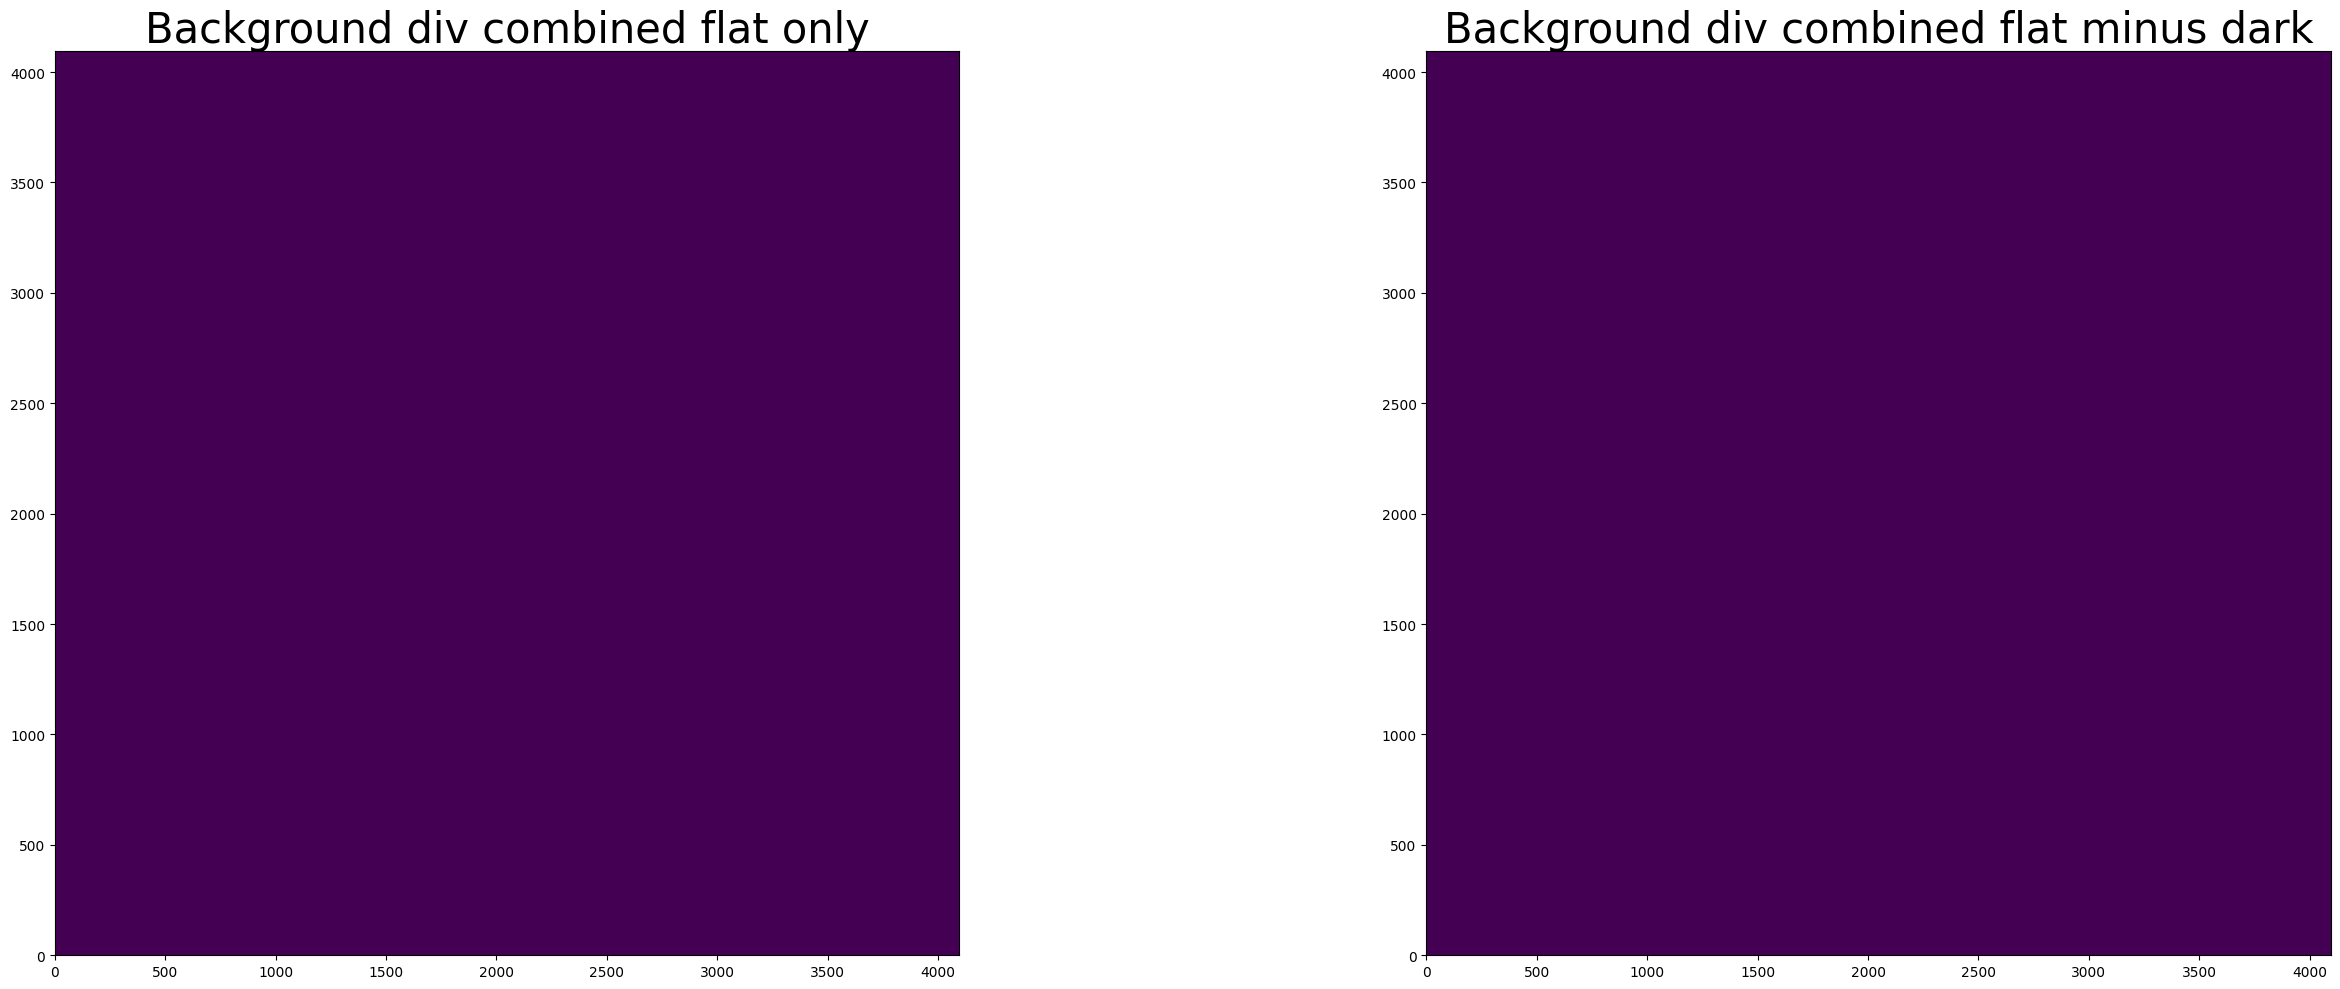

In [43]:
## Plotting:
# Use the following line to find estimates for vmin and vmax
#show_image(bkg.background, cmap='gray', percl=90)

figs, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 10))

ax1.imshow(bkg.background, vmin=235, vmax=255, origin='lower')
ax1.set_title('Background div combined flat only',fontsize=30)

ax2.imshow(bkgs.background, vmin=235, vmax=255, origin='lower')
ax2.set_title('Background div combined flat minus dark',fontsize=30)
plt.tight_layout()
#figs.savefig("Wasp12b-2D_bckg_comparison2.png")

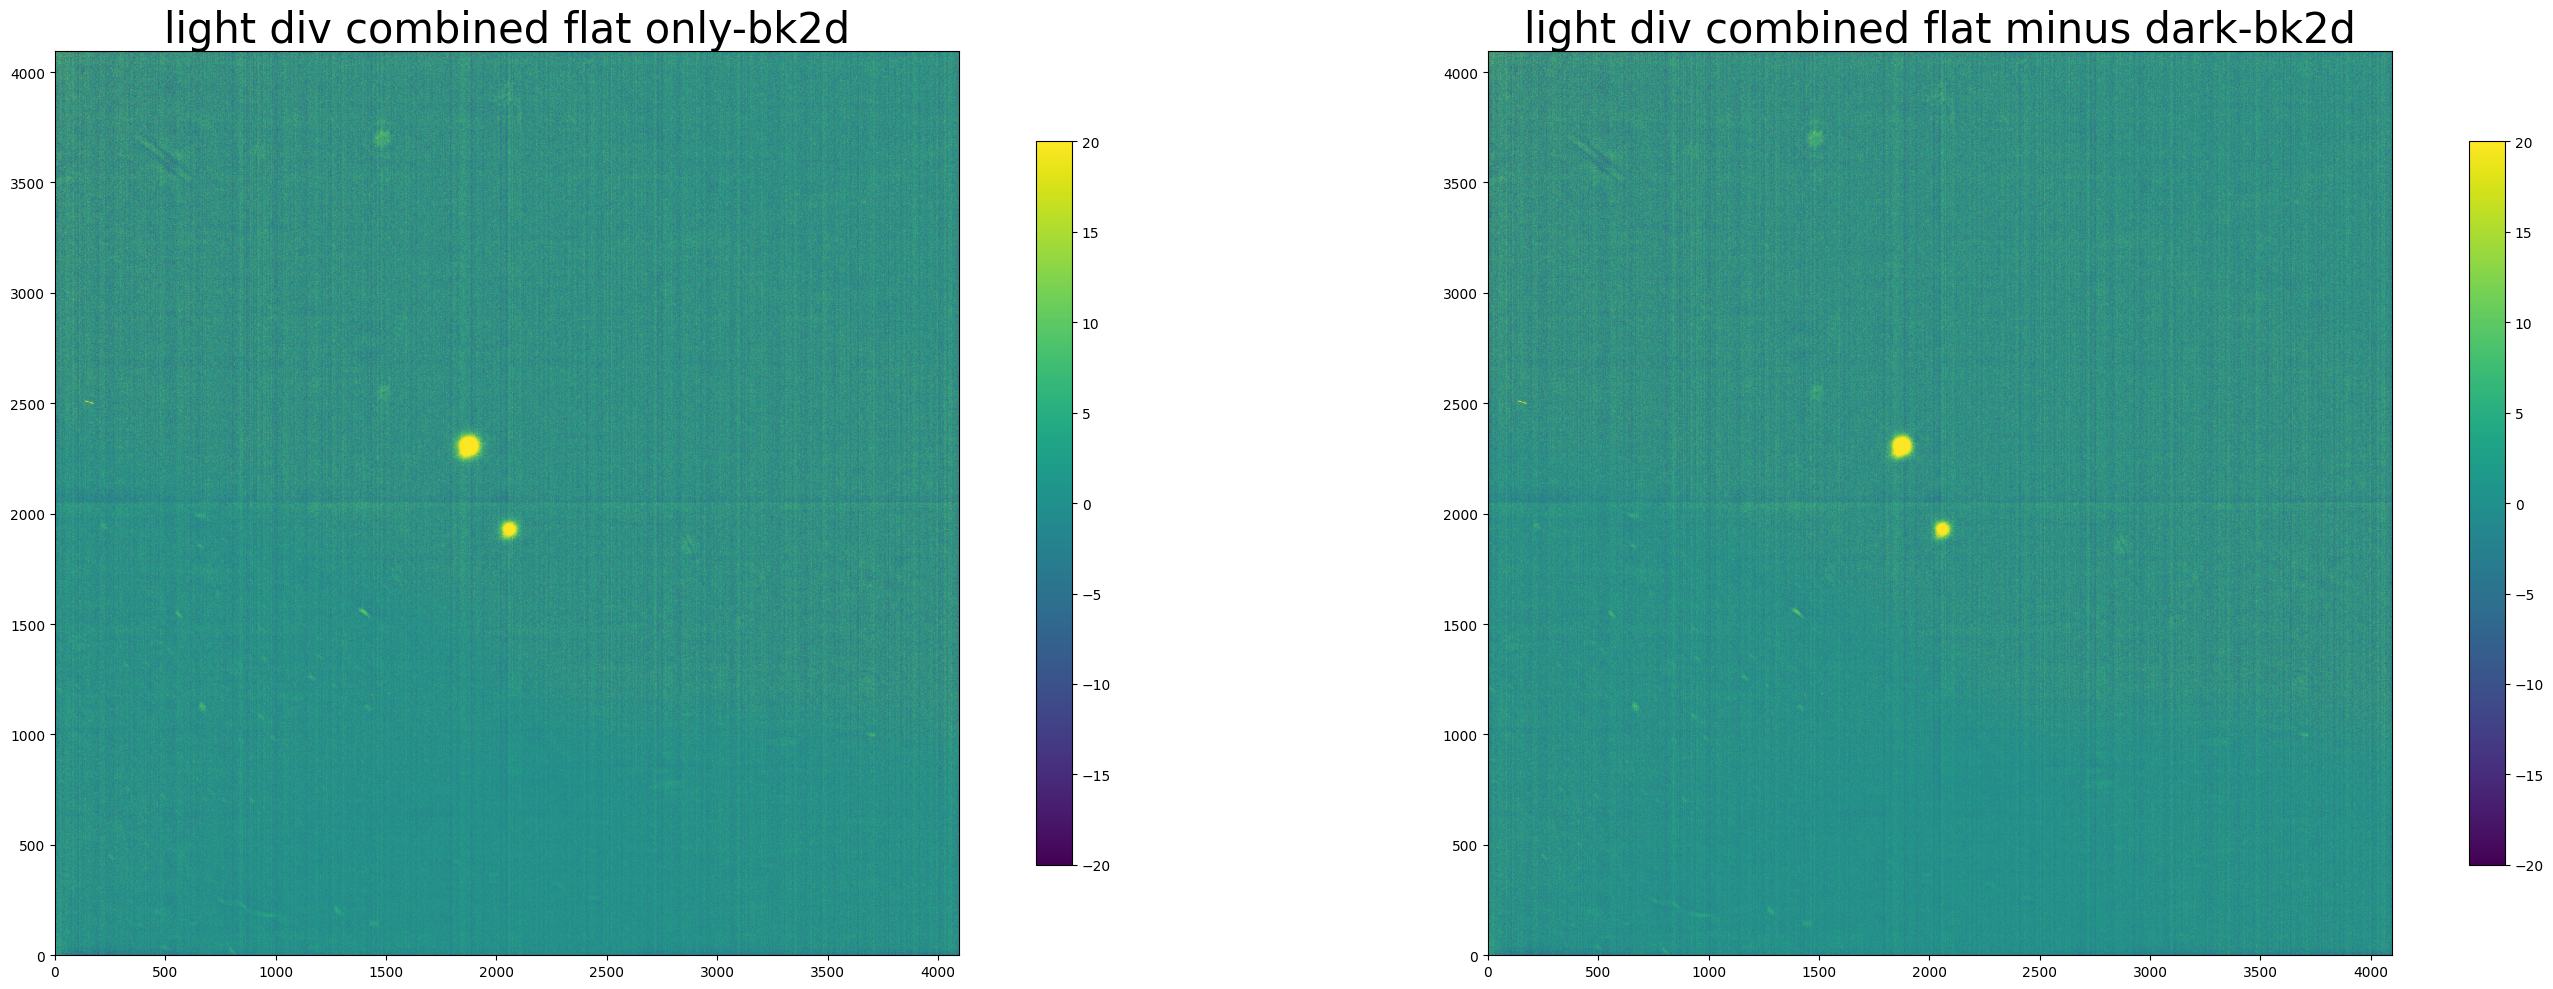

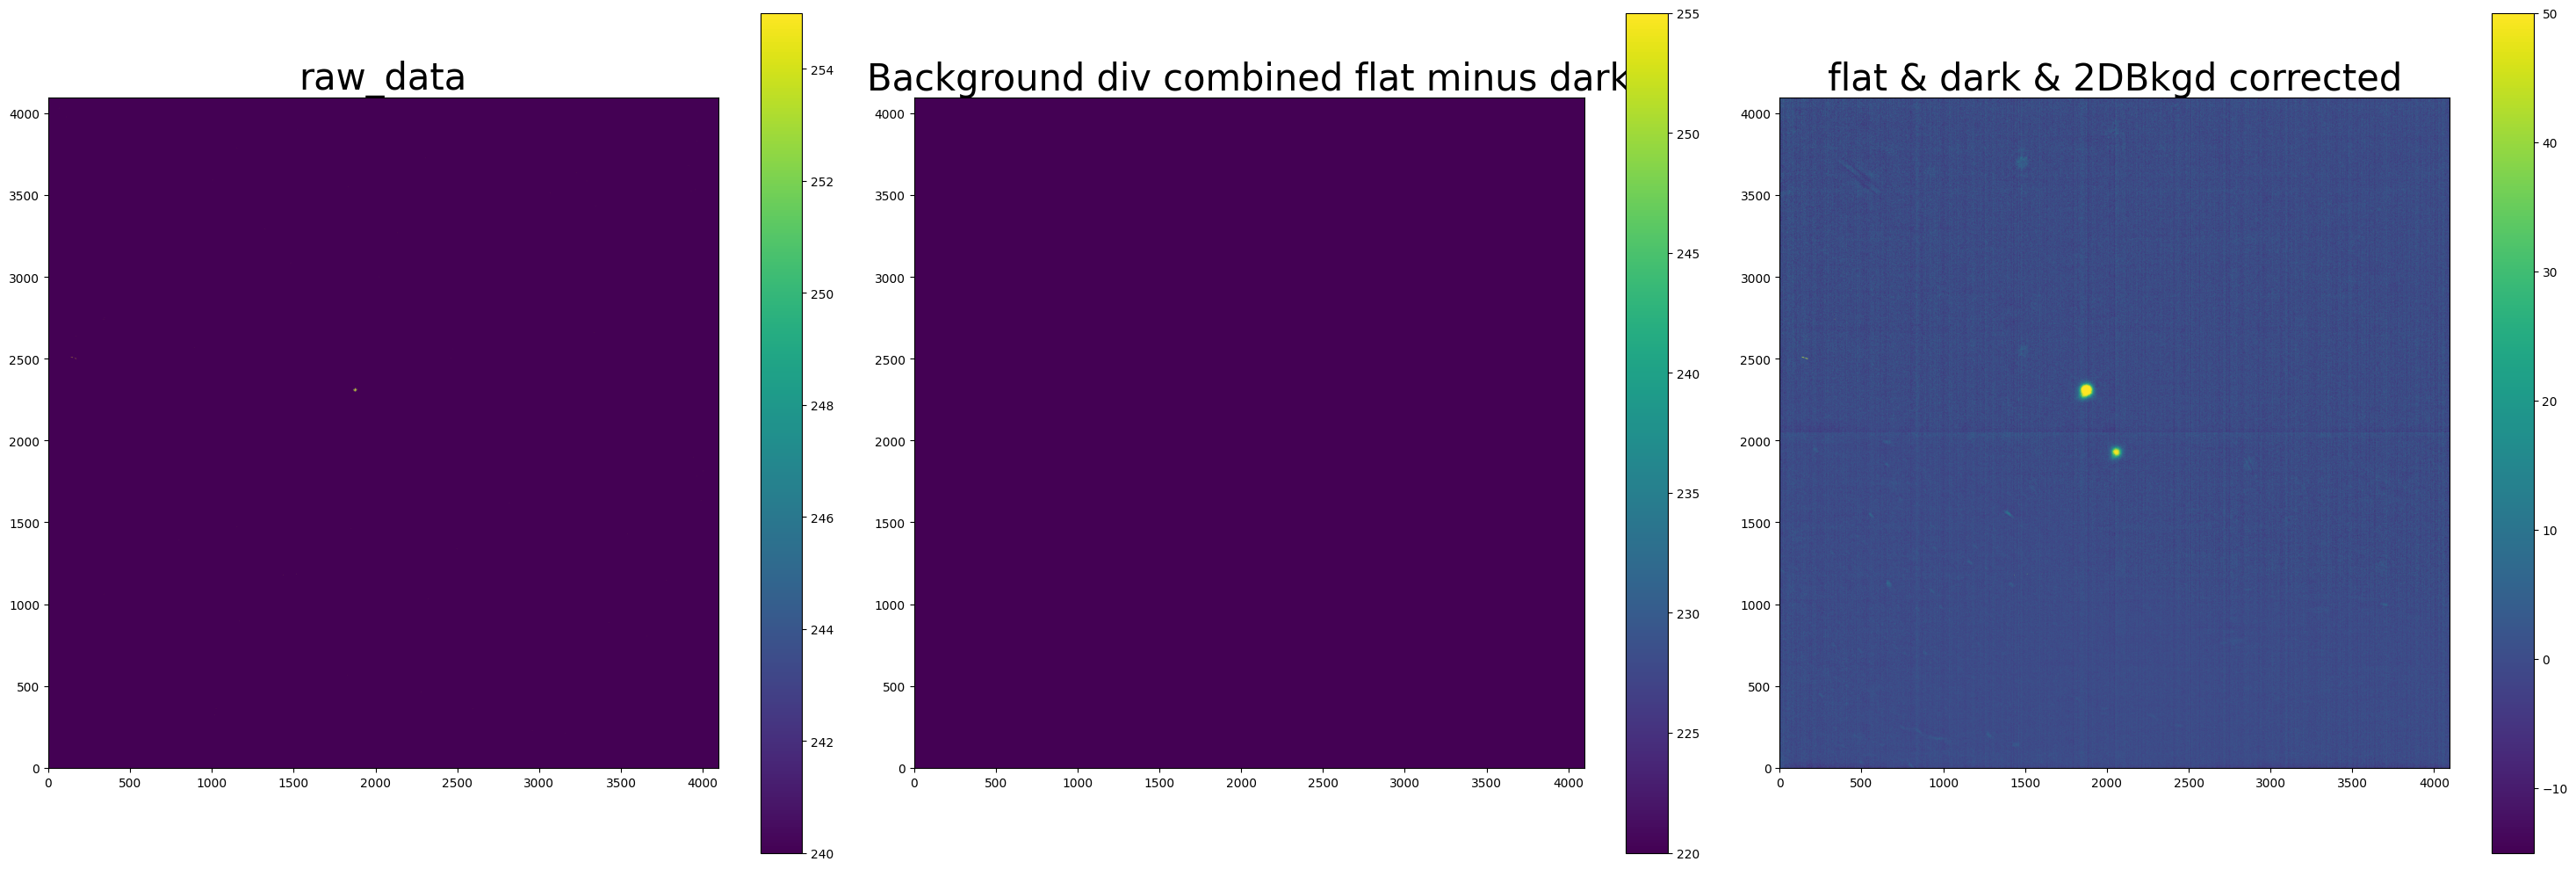

In [44]:
## STEP 7. Subtracting Background

#show_image(raw_data, cmap='gray',percl=90)
#show_image(reducefd.data- bkgs.background, cmap='gray',percl=90)

figd, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 10))
im1 = ax1.imshow(reduceflat.data - bkg.background, vmin=-20, vmax=20, origin='lower')
ax1.set_title('light div combined flat only-bk2d', fontsize=30)
im2 = ax2.imshow(reducefd.data - bkgs.background, vmin=-20, vmax=20, origin='lower')
ax2.set_title('light div combined flat minus dark-bk2d', fontsize=30)

# Add colorbars
figd.colorbar(im1, ax=ax1, orientation='vertical', shrink=0.8)
figd.colorbar(im2, ax=ax2, orientation='vertical', shrink=0.8)

plt.tight_layout()
plt.show()
#figd.savefig("030421_Wasp12b_calibration_v2.png")


figy, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(30, 10))
iu1 = ax1.imshow(raw_data, vmin=240, vmax=255, origin='lower')
ax1.set_title('raw_data', fontsize=30)
iu2 = ax2.imshow(bkgs.background, vmin=220, vmax=255, origin='lower')
ax2.set_title('Background div combined flat minus dark', fontsize=30)
iu3 = ax3.imshow(reducefd.data - bkgs.background, vmin=-15, vmax=50, origin='lower')
ax3.set_title('flat & dark & 2DBkgd corrected', fontsize=30)


# Add colorbars
figy.colorbar(iu1, ax=ax1, orientation='vertical')
figy.colorbar(iu2, ax=ax2, orientation='vertical')
figy.colorbar(iu3, ax=ax3, orientation='vertical')
#figy.colorbar(iu3, ax=ax3, orientation='vertical', shrink=0.7)

plt.tight_layout()
plt.show()
#figy.savefig("Wasp12b-flat2-fld2Dbkg.png")

In [49]:
## STEP 8. Writing the cleaned light frame to calibrated folder
light_frame_base = light_frame_name.rsplit('.', 1)[0]
print(light_frame_base)

flatonly = reduceflat.data - bkgs.background
flatonly_ccd = CCDData(data=flatonly, header=raw_data.header, unit=raw_data.unit) 
output_flatname = f"{light_frame_base}"
fits.writeto(calibrated_path / output_flatname, flatonly_ccd.data, 
            header=flatonly_ccd.header, overwrite=True)


flatanddark = reducefd.data - bkg.background
flatanddark_ccd = CCDData(data=flatanddark, header=raw_data.header, unit=raw_data.unit)
output_fdname = f"{light_frame_base}"
fits.writeto(calibrated_path / output_fdname, flatanddark_ccd.data, 
            header=flatanddark_ccd.header, overwrite=True)

i_science_2025_05_06_1x1_-15.0C_exp00.00.01.000_High_47


In [ ]:
## STEP 9. Performing all the above tasks for all light frames

# Read the combined flat frame
comb_flat = CCDData.read(combined_flat_file)

files = ccdp.ImageFileCollection(path)
light_frame_files = files.files_filtered(include_path=True, OBSTYPE='object')

for light_frame_file in light_frame_files:  # Assuming the light frame files are .fits

    raw_data = CCDData.read(light_frame_file, unit='adu')

    # Performing subtraction of dark from light
    reducedark = ccdp.subtract_dark(raw_data, combined_dark, exposure_time='EXPTIME', exposure_unit=u.second)

    # Light minus Flat and Dark
    reducefd = ccdp.flat_correct(reducedark, comb_flat)

    # Prepare output filenames
    file_path = Path(light_frame_file)
    file_name = file_path.stem
    output_light_minus_dark = combined_path / (f'light_minus_dark_only_{file_name}.fits')
    output_light_div_flat_minus_dark = combined_path / (f'light_div_flat_minus_dark_{file_name}.fits')

    # Check if output files already exist
    if output_light_minus_dark.exists():
        print(f"File already exists: {output_light_minus_dark}")
    else:
        reducedark.write(output_light_minus_dark, overwrite=True)

    if output_light_div_flat_minus_dark.exists():
        print(f"File already exists: {output_light_div_flat_minus_dark}")
    else:
        reducefd.write(output_light_div_flat_minus_dark, overwrite=True)

    # Source Detection and Masking for creating 2D background
    sigma_clip = SigmaClip(sigma=3.0, maxiters=10)

    # Thresholding for light minus flat only (reduceflat)
    reduceflat = ccdp.flat_correct(raw_data, comb_flat)
    threshold_flat = detect_threshold(reduceflat.data, nsigma=5, sigma_clip=sigma_clip)
    segment_img_flat = detect_sources(reduceflat.data, threshold_flat, npixels=10)
    footprint_flat = circular_footprint(radius=3)
    mask_flat = segment_img_flat.make_source_mask(footprint=footprint_flat)

    # Thresholding for light div flat minus dark (reducefd)
    threshold_fd = detect_threshold(reducefd.data, nsigma=5, sigma_clip=sigma_clip)
    segment_img_fd = detect_sources(reducefd.data, threshold_fd, npixels=10)
    footprint_fd = circular_footprint(radius=3)
    mask_fd = segment_img_fd.make_source_mask(footprint=footprint_fd)

    # Background Estimation for light div flat minus dark (reducefd)
    bkg_estimators = MedianBackground()
    bkg_fd = Background2D(reducefd.data, (50, 50), mask=mask_fd, filter_size=(3, 3), 
                          sigma_clip=sigma_clip, bkg_estimator=bkg_estimators)

    # Subtracting Background
    flatanddark = reducefd.data - bkg_fd.background
    flatanddark_ccd = CCDData(data=flatanddark, header=raw_data.header, unit=raw_data.unit)

    # Writing the output to a new file
    calibrated_darkandflat = f"{file_name}_calibrated_darkandflat.fits"
    output_fdname = calibrated_path / calibrated_darkandflat
    fits.writeto(output_fdname, flatanddark_ccd.data, header=flatanddark_ccd.header, overwrite=True)

    print(f"Processed and saved {output_fdname}")